In [1]:
# Supply chain analysis of feedstock cost impact on MJSP
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, additional_rcf
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank


In [2]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

In [4]:
etoh_system = create_cellulosic_ethanol_system(ins=poplar_in, add_denaturant=False)
etoh_system.simulate()

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()


# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: NH3 has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\design_tools\tank_design.py:107: CostWarning: volume (0 gal) is below the lower bound (30000 gal) for purchase cost estimation
  warn(f"volume ({V_total:.5g} {V_units}) is below "
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Ethylene has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-pac

In [5]:
# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.

etoh_ww = [F.pretreatment_wastewater, F.unit.S401.outs[1]]

etoh_solids = [F.unit.S401.outs[0]]

WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.ETJ_WW_OUTS] + etoh_ww)
F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)

BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])

gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF




In [6]:
h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

h2_storage = HydrogenStorageTank('H2_TK', ins=h2_etj)


In [7]:
etoh_etj_system = bst.System(
    'Cellulosic_ETJ',
    path=(etoh_system, nh3_splitter, etj_system, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_storage, BT],
)

etoh_etj_system.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:986: RuntimeWarning: the purchase cost item, 'Total Cost', has no defined bare-module factor in the 'HydrogenStorageTank.F_BM' dictionary; bare-module factor now has a default value of 1
  warn(f"the purchase cost item, '{name}', has "


In [8]:
#etoh_etj_system.save_report()

In [9]:
F.ETJ_H2_IN.price = prices['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = prices['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = prices['renewable_diesel']    # 1.888 USD/kg
F.sulfuric_acid.price = prices['H2SO4']
F.ammonia.price = prices['NH3']
F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 
#F.FOD_lime.price = prices['FOD_lime']


integrated_tea = create_cellulosic_ethanol_tea(etoh_etj_system)

In [10]:
# Default TEA duration is (2016, 2046) -> 30 operating years.
plant_start_year, plant_end_year = 2016, 2046
n_operating_years = plant_end_year - plant_start_year
rng = np.random.default_rng(0)   # seeded for a reproducible demo run
operating_days_schedule = rng.integers(250, 331, size=n_operating_years)   # 331 exclusive -> inclusive of 330

In [11]:
operating_days_schedule

array([318, 301, 291, 271, 274, 253, 256, 251, 264, 315, 302, 323, 290,
       299, 328, 309, 301, 294, 295, 325, 272, 316, 304, 250, 281, 319,
       294, 252, 311, 309], dtype=int64)

In [12]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [13]:


# Baseline TEA: constant 330 days/yr (the historical default).
baseline_tea = create_cellulosic_ethanol_tea(
    etoh_etj_system,
    operating_days=330,
    duration=(plant_start_year, plant_end_year),
)
baseline_tea.labor_cost = labor

# Duplicate TEA wrapping the SAME simulated system, but with a random
# 250-330 days/yr schedule instead of a constant. This is a genuinely
# independent TEA object -- MultiYearCellulosicEthanolTEA keeps its own
# private operating_hours rather than sharing/overwriting
# etoh_etj_system.operating_hours, so building this second TEA does not
# perturb baseline_tea's numbers (see the class docstring in cellulosic_tea.py).
variable_tea = create_cellulosic_ethanol_tea(
    etoh_etj_system,
    operating_days=operating_days_schedule,
    duration=(plant_start_year, plant_end_year),
)
variable_tea.labor_cost = labor

print('Operating days schedule [days/yr]:')
print(operating_days_schedule)

baseline_npv = baseline_tea.NPV
variable_npv = variable_tea.NPV
print(f'Baseline (constant 330 days/yr) NPV: {baseline_npv/1e6:,.2f} MM$')
print(f'Variable (random 250-330 days/yr) NPV: {variable_npv/1e6:,.2f} MM$')

# Confirms the two TEAs are truly independent: re-reading baseline_tea.NPV
# after variable_tea was built (and evaluated) still gives the same value.
assert baseline_tea.NPV == baseline_npv, 'baseline_tea was clobbered by variable_tea!'

Operating days schedule [days/yr]:
[318 301 291 271 274 253 256 251 264 315 302 323 290 299 328 309 301 294
 295 325 272 316 304 250 281 319 294 252 311 309]
Baseline (constant 330 days/yr) NPV: -8,465.60 MM$
Variable (random 250-330 days/yr) NPV: -7,771.22 MM$


In [14]:
variable_mjsp = round(((variable_tea.solve_price(F.ETJ_SAF_OUT)*F.ETJ_SAF_OUT.rho)/264.172),2)
baseline_mjsp = round(((baseline_tea.solve_price(F.ETJ_SAF_OUT)*F.ETJ_SAF_OUT.rho)/264.172),2)

In [15]:
F.ETJ_SAF_OUT.price = (variable_mjsp/F.ETJ_SAF_OUT.rho)*264.172

In [16]:
variable_tea.get_cashflow_table().to_excel('variable_cash_flow.xlsx')

In [ ]:
#baseline_tea.get_cashflow_table().to_excel('baseline_cash_flow.xlsx')

In [ ]:
baseline_mjsp

7.14

In [ ]:
variable_mjsp

7.14

In [ ]:
BREAK

NameError: name 'BREAK' is not defined

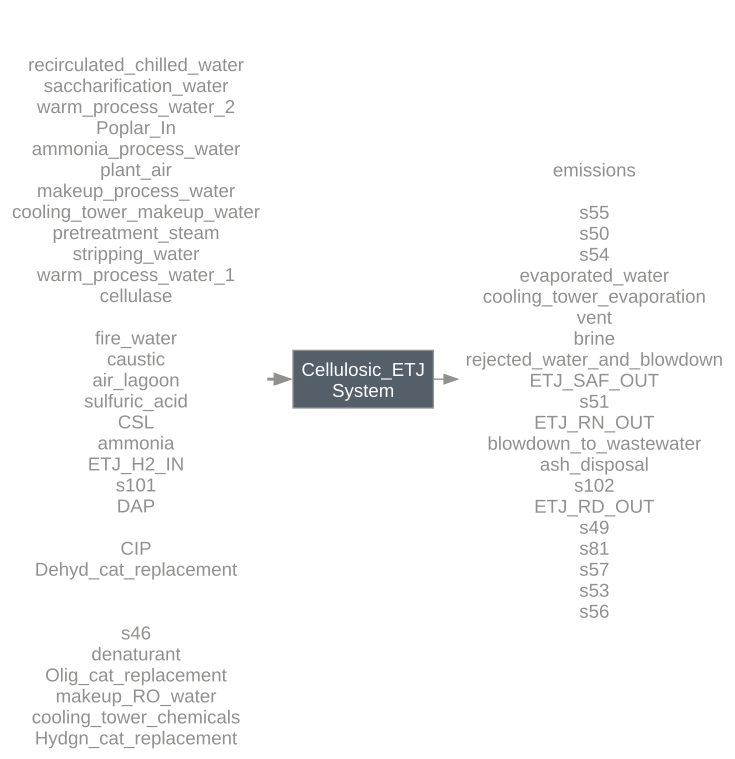

System: Cellulosic_ETJ
Highest convergence error among components in recycle
streams {ETJ_SPLIT1-1, ETJ_SPLIT2-0, ETJ_SPLIT3-0} after 1 loops:
- flow rate   4.76e-02 kmol/hr (0.004%)
- temperature 1.57e-09 K (2.5e-10%)
ins...
[0] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water     4.63e+03
                    Sucrose   1.22
                    Extract   37
                    Acetate   243
                    Ash       5e+03
                    Lignin    780
                    Glucan    1.19e+03
                    Xylan     423
                    Arabinan  6.31
                    Mannan    95.1
                    Galactan  36
[1] warm_process_water_1  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  6.52e+03
[2] pretreatment_steam  
    phase: 'g', T: 541.15 K, P: 1.31722e+06 Pa
    flow (kmol/hr): Water  8.8e+03
[3] warm_process_water_2  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  4.39e+04
[4] ammonia_

In [ ]:
etoh_etj_system

In [ ]:
integrated_tea.operating_days = 330
mjsp = round(((integrated_tea.solve_price(F.ETJ_SAF_OUT)*F.ETJ_SAF_OUT.rho)/264.172),2)

print(f'The MSP for SAF blend is  {mjsp} USD/gal')

AttributeError: cannot set a single 'operating_days' value on 'MultiYearCellulosicEthanolTEA'; set 'operating_days_schedule' instead (one value per operating year)

In [ ]:
#bst.nbtutorial()

In [ ]:
#etoh_etj_system.diagram()

In [ ]:
F.ETJ_SAF_OUT

Stream: ETJ_SAF_OUT from <HydrocarbonProductTank: ETJ_TK2>
phase: 'l', T: 288.15 K, P: 101325 Pa
flow (kmol/hr): Ethanol     0.101
                Hexane      3.14
                Decane      310
                Octadecane  3.13


In [ ]:
bst.BinaryDistillation

biosteam.units.distillation.BinaryDistillation

In [ ]:
bst.Stripper

biosteam.units.distillation.AdiabaticMultiStageVLEColumn

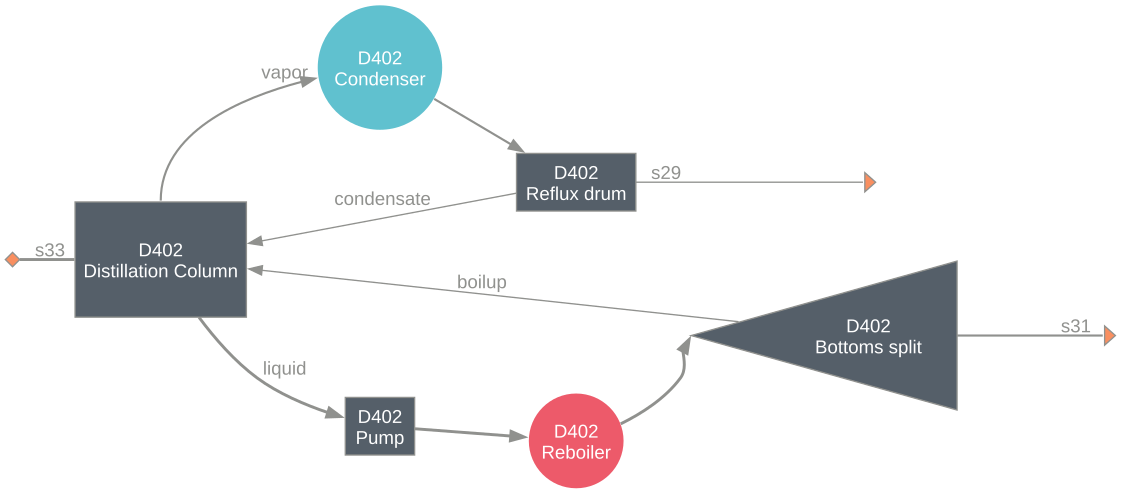

BinaryDistillation: D402
ins...
[0] s33  from  HXprocess-H401
    phase: 'l', T: 379.99 K, P: 607950 Pa
    flow (kmol/hr): Water              1.49e+05
                    Ethanol            2.52e+03
                    AceticAcid         200
                    Furfural           11.1
                    Glycerol           10.3
                    NH3                0.818
                    LacticAcid         101
                    SuccinicAcid       18.3
                    DAP                8.17
                    AmmoniumSulfate    91.8
                    HMF                5.19
                    Glucose            19
                    Xylose             24.5
                    Arabinose          5.51
                    Extract            37
                    Ash                5e+03
                    Lignin             741
                    SolubleLignin      39
                    GlucoseOligomer    46.3
                    GalactoseOligomer  0.863
              

In [ ]:
F.D402

In [ ]:
F.D403.outs[0].show(composition=True)

Stream: s35 from <BinaryDistillation: D403> to <HXutility: H402>
phase: 'g', T: 363.94 K, P: 162120 Pa
composition (%): Water    19.2
                 Ethanol  80.8
                 NH3      0.022
                 -------  3.72e+03 kmol/hr


In [ ]:
F.ETJ_RN_OUT

Stream: ETJ_RN_OUT from <HydrocarbonProductTank: ETJ_TK1>
phase: 'l', T: 212.63 K, P: 101325 Pa
flow (kmol/hr): Ethanol   0.101
                Hydrogen  5.9e-08
                Hexane    122
                Butane    215
                Decane    1.23
